# Classification of ICD10 Code depending on Symtoms 

## Import files

In [1]:
import io
import csv
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

## Insert data

In [2]:
with open("./Symptom2Disease.csv", 'r') as csvfile:
    # Print the first five lines of the file
    for i in range(5):
        line = csvfile.readline()
        print(line)


Disease,Symptoms

A01.0(TYPHOID),"I've also been suffering from diarrhea, which has been really uncomfortable. It comes and goes, and it's accompanied by stomach aches and vomiting."

A01.0(TYPHOID),I am having severe stomach discomfort and diarrhoea. I have a high fever along with a headache. The previous several days have been really unpleasant.

A01.0(TYPHOID),"The abdominal pain has been coming and going, and it's been really unpleasant. It's been accompanied by constipation and vomiting. I feel really concerned about my health."

A01.0(TYPHOID),"I've also been experiencing some diarrhea and constipation, which has been really worrying. It feels like a sharp, stabbing pain in my belly area. I feel tired all the time."



In [3]:
with open("./Symptom2Disease_50.csv", 'r') as csvfile:
    # Print the first five lines of the file
    for i in range(5):
        line = csvfile.readline()
        print(line)

Disease,Symptoms

A01.0(TYPHOID),"I am having some diarrhea and constipation, which has been quite concerning. In my stomach, there is a severe, painful ache. I'm constantly exhausted and don't feel like eating anything."

A01.0(TYPHOID),"I've been having diarrhoea and loose, watery stools many times a day. I've lost my appetite and am always sick. I'm also developing a mild fever. Also, my abdominal part pains a lot. I don't know what the reason behind all of these is."

A01.0(TYPHOID),"I've been having a lot of trouble staying hydrated because of the vomiting and diarrhea. I have a high fever, constipation, and a headache. I am also starting to get a strange pain in my stomach area and I can't do anything physical."

A01.0(TYPHOID),"I've lost a lot of weight in the last week because I couldn't eat much due to nausea and vomiting. This is followed by a high fever, headache, and stomach pain."



## Defining useful global variables

In [4]:
NUM_WORDS = 1000
EMBEDDING_DIM = 16
MAXLEN = 120
PADDING = 'post'
OOV_TOKEN = "<OOV>"
TRAINING_SPLIT = .8

## Loading and pre-processing the data

In [5]:
def remove_stopwords(sentence):
  
    # List of stopwords
    stopwords = ["a", "about", "above", "after", "again", "against", "all", "am", "an", "and", "any", "are", "as", "at", "be", "because", "been", "before", "being", "below", "between", "both", "but", "by", "could", "did", "do", "does", "doing", "down", "during", "each", "few", "for", "from", "further", "had", "has", "have", "having", "he", "he'd", "he'll", "he's", "her", "here", "here's", "hers", "herself", "him", "himself", "his", "how", "how's", "i", "i'd", "i'll", "i'm", "i've", "if", "in", "into", "is", "it", "it's", "its", "itself", "let's", "me", "more", "most", "my", "myself", "nor", "of", "on", "once", "only", "or", "other", "ought", "our", "ours", "ourselves", "out", "over", "own", "same", "she", "she'd", "she'll", "she's", "should", "so", "some", "such", "than", "that", "that's", "the", "their", "theirs", "them", "themselves", "then", "there", "there's", "these", "they", "they'd", "they'll", "they're", "they've", "this", "those", "through", "to", "too", "under", "until", "up", "very", "was", "we", "we'd", "we'll", "we're", "we've", "were", "what", "what's", "when", "when's", "where", "where's", "which", "while", "who", "who's", "whom", "why", "why's", "with", "would", "you", "you'd", "you'll", "you're", "you've", "your", "yours", "yourself", "yourselves" ]
    
    # Sentence converted to lowercase-only
    sentence = sentence.lower()

    words = sentence.split()
    no_words = [w for w in words if w not in stopwords]
    sentence = " ".join(no_words)

    return sentence

In [6]:
def parse_data_from_file(filename):

    sentences = []
    labels = []
    with open(filename, 'r') as csvfile:
        reader = csv.reader(csvfile, delimiter=',')
        next(reader)
        for row in reader:
            labels.append(row[0])
            sentence = row[1]
            sentence = remove_stopwords(sentence)
            sentences.append(sentence)

    return sentences, labels

In [7]:
# Test the functions
sentences, labels = parse_data_from_file("./Symptom2Disease.csv")

print(f"There are {len(sentences)} sentences in the dataset.\n")
print(f"First sentence has {len(sentences[0].split())} words (after removing stopwords).\n")
print(f"There are {len(labels)} labels in the dataset.\n")
print(f"The first 5 labels are {labels[:5]}")

There are 1080 sentences in the dataset.

First sentence has 11 words (after removing stopwords).

There are 1080 labels in the dataset.

The first 5 labels are ['A01.0(TYPHOID)', 'A01.0(TYPHOID)', 'A01.0(TYPHOID)', 'A01.0(TYPHOID)', 'A01.0(TYPHOID)']


In [8]:
# Convert list of labels to a set to find unique labels
unique_labels = set(labels)

# Print the unique labels
print(f"There are {len(unique_labels)} unique labels in the dataset.")
print("Unique labels:", unique_labels)


There are 24 unique labels in the dataset.
Unique labels: {'K21.9(GASTROESOPHAGEAL_REFLUX_DISEASE)', 'J00(COMMON_COLD)', 'T78.40XA(ALLERGY)', 'I10(HYPERTENSION)', 'J15.9(PNEUMONIA)', 'A01.0(TYPHOID)', 'K64.8(DIMORPHIC_HEMORRHOIDS)', 'N39.0(URINARY_TRACT_INFECTION)', 'B50.9(MALARIA)', 'B01.9(CHICKEN_POX)', 'E089(DIABETES)', 'M47.892(CERVICAL_SPONDYLOSIS)', 'K27.9(PEPTIC_ULCER_DISEASE)', 'M13.80(ARTHRITIS)', 'J45.909(BRONCHI_ALASTHMA)', 'R17(JAUNDICE)', 'B49(FUNGAL_INFECTION)', 'A90(DENGUE)', 'G43.909(MIGRAINE)', 'I83.899(VARICOSE_VEINS)', 'L40.0(PSORIASIS)', 'T88.7XXA(DRUG_REACTION)', 'L01.00(IMPETIGO)', 'L70.9(ACNE)'}


In [9]:

# Test the functions
sentences1, labels1 = parse_data_from_file("./Symptom2Disease_50.csv")

print(f"There are {len(sentences1)} sentences in the dataset.\n")
print(f"First sentence has {len(sentences1[0].split())} words (after removing stopwords).\n")
print(f"There are {len(labels1)} labels in the dataset.\n")
print(f"The first 5 labels are {labels1[:5]}")

There are 120 sentences in the dataset.

First sentence has 15 words (after removing stopwords).

There are 120 labels in the dataset.

The first 5 labels are ['A01.0(TYPHOID)', 'A01.0(TYPHOID)', 'A01.0(TYPHOID)', 'A01.0(TYPHOID)', 'A01.0(TYPHOID)']


## Training - Validation Split

def train_val_split(sentences, labels, training_split):
 
    # Compute the number of sentences that will be used for training (should be an integer)
    train_size = int(len(sentences) * training_split)

    # Split the sentences and labels into train/validation splits
    train_sentences = sentences[:train_size]
    train_labels = labels[:train_size]

    validation_sentences = sentences[train_size:]
    validation_labels = labels[train_size:]
     
    return train_sentences, validation_sentences, train_labels, validation_labels

# Test your function
train_sentences, val_sentences, train_labels, val_labels = train_val_split(sentences, labels, TRAINING_SPLIT)

print(f"There are {len(train_sentences)} sentences for training.\n")
print(f"There are {len(train_labels)} labels for training.\n")
print(f"There are {len(val_sentences)} sentences for validation.\n")
print(f"There are {len(val_labels)} labels for validation.")

print(f"First 5 Sentences of the training set should look like this:\n{train_sentences[:2]}\n")
print(f"First 5 Sentences of the validation set should look like this:\n{val_sentences[:5]}\n")

## Tokenization - Sequences and padding

In [10]:
def fit_tokenizer(sentences, num_words, oov_token):
    
    # Instantiate the Tokenizer class, passing in the correct values for num_words and oov_token
    tokenizer = Tokenizer(num_words= 1000 ,oov_token="<OOV>")
    
    # Fit the tokenizer to the training sentences
    tokenizer.fit_on_texts(sentences)
        
    return tokenizer

In [11]:
# Test function
tokenizer = fit_tokenizer(sentences, NUM_WORDS, OOV_TOKEN)
word_index = tokenizer.word_index

print(f"Vocabulary contains {len(word_index)} words\n")
print("<OOV> token included in vocabulary" if "<OOV>" in word_index else "<OOV> token NOT included in vocabulary")

tokenizer = fit_tokenizer(sentences1, NUM_WORDS, OOV_TOKEN)
word_index = tokenizer.word_index

print(f"Vocabulary contains {len(word_index)} words\n")
print("<OOV> token included in vocabulary" if "<OOV>" in word_index else "<OOV> token NOT included in vocabulary")

Vocabulary contains 1441 words

<OOV> token included in vocabulary
Vocabulary contains 642 words

<OOV> token included in vocabulary


In [12]:
def seq_and_pad(sentences, tokenizer, padding, maxlen):
    
    # Convert sentences to sequences
    sequences = tokenizer.texts_to_sequences(sentences)
    
    # Pad the sequences using the correct padding and maxlen
    padded_sequences = pad_sequences(sequences,padding='post', maxlen=40)
       
    return padded_sequences

In [13]:
# Test function
train_padded_seq = seq_and_pad(sentences, tokenizer, PADDING, MAXLEN)
val_padded_seq = seq_and_pad(sentences1, tokenizer, PADDING, MAXLEN)

print(f"Padded training sequences have shape: {train_padded_seq.shape}\n")
print(f"Padded validation sequences have shape: {val_padded_seq.shape}")

Padded training sequences have shape: (1080, 40)

Padded validation sequences have shape: (120, 40)


In [14]:
print(f"First 5 Sentences of the training set should look like this:\n{train_padded_seq[:5]}\n")
print(f"First 5 Sentences of the validation set should look like this:\n{val_padded_seq[:5]}\n")

First 5 Sentences of the training set should look like this:
[[  2 193 154  10 204   1   1 163  25 288  43   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [ 15  25  40 336   8   7  60  19   1   1  97  10 319   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [157   3   1 518  10 319 163  90  43   9  10 307 170   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [  2   6 154  90  10 246 133  27   1   1   3   1 343   9  29  16   0   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]
 [211  10 204   4 451   1 126   2  11  10   1   1 235   3 157 339 166   0
    0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0]]

First 5 Sentences of the validation set should look like this:
[[154  90  18 334  25  15  31 335  91  

In [15]:
def setup_tokenizer(all_labels):
    label_tokenizer = Tokenizer(filters='', lower=False)  # No filtering, maintain original case
    label_tokenizer.fit_on_texts(all_labels)
    return label_tokenizer
    
def tokenize_labels(label_tokenizer, labels):
    # Convert labels to sequences using the tokenizer
    label_seq = label_tokenizer.texts_to_sequences(labels)
    
    # Flatten the list of lists to a single list, adjusting indices to be 0-based
    label_seq_np = np.array([item[0] - 1 for item in label_seq])
    
    # Reshape to (n, 1) for compatibility with TensorFlow/Keras
    label_seq_np = label_seq_np.reshape(-1, 1)
    
    return label_seq_np


In [16]:
# Setup the tokenizer with all possible labels
# label_tokenizer = setup_tokenizer(labels)
all_labels = labels + labels1

# Setup the tokenizer with all possible labels
label_tokenizer = setup_tokenizer(all_labels)

# Tokenize training and validation labels using the established tokenizer
train_label_seq = tokenize_labels(label_tokenizer, labels)
val_label_seq = tokenize_labels(label_tokenizer, labels1)

# Output for debugging
print(f"First 5 labels of the training set should look like this:\n{train_label_seq[:5]}\n")
print(f"First 5 labels of the validation set should look like this:\n{val_label_seq[:5]}\n")

print(f"Tokenized labels of the training set have shape: {train_label_seq.shape}\n")
print(f"Tokenized labels of the validation set have shape: {val_label_seq.shape}\n")


First 5 labels of the training set should look like this:
[[0]
 [0]
 [0]
 [0]
 [0]]

First 5 labels of the validation set should look like this:
[[0]
 [0]
 [0]
 [0]
 [0]]

Tokenized labels of the training set have shape: (1080, 1)

Tokenized labels of the validation set have shape: (120, 1)



In [17]:
import numpy as np

# Combine labels from both sets for tokenizer setup
all_labels = labels + labels1

# Setup the tokenizer with all possible labels
label_tokenizer = setup_tokenizer(all_labels)

# Tokenize training and validation labels using the established tokenizer
train_label_seq = tokenize_labels(label_tokenizer, labels)
val_label_seq = tokenize_labels(label_tokenizer, labels1)

# Output for debugging
print(f"First 5 labels of the training set should look like this:\n{train_label_seq[:5]}\n")
print(f"First 5 labels of the validation set should look like this:\n{val_label_seq[:5]}\n")

print(f"Tokenized labels of the training set have shape: {train_label_seq.shape}\n")
print(f"Tokenized labels of the validation set have shape: {val_label_seq.shape}\n")

# Check unique labels after tokenization
unique_train_labels = np.unique(train_label_seq)
unique_val_labels = np.unique(val_label_seq)

print(f"Unique labels in the training set after tokenization: {unique_train_labels}")
print(f"Unique labels in the validation set after tokenization: {unique_val_labels}")


First 5 labels of the training set should look like this:
[[0]
 [0]
 [0]
 [0]
 [0]]

First 5 labels of the validation set should look like this:
[[0]
 [0]
 [0]
 [0]
 [0]]

Tokenized labels of the training set have shape: (1080, 1)

Tokenized labels of the validation set have shape: (120, 1)

Unique labels in the training set after tokenization: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Unique labels in the validation set after tokenization: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


## Selecting the model for text classification

Now that the data is ready to be fed a Neural Network

In [18]:
def create_model(num_words, embedding_dim, maxlen):
 
    tf.random.set_seed(123)
    
    model = tf.keras.Sequential([ 
        tf.keras.layers.Embedding(num_words, embedding_dim, input_length=40),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(24, activation='softmax'),

    ])
    
    model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy']) 

    return model

In [19]:
model = create_model(NUM_WORDS, EMBEDDING_DIM, MAXLEN)

history = model.fit(train_padded_seq, train_label_seq, epochs=30, validation_data=(val_padded_seq, val_label_seq))



Epoch 1/30


34/34 [==============================] - 3s 26ms/step - loss: 3.1700 - accuracy: 0.0630 - val_loss: 3.1511 - val_accuracy: 0.1083
Epoch 2/30
34/34 [==============================] - 0s 8ms/step - loss: 3.1161 - accuracy: 0.3370 - val_loss: 3.1077 - val_accuracy: 0.3833
Epoch 3/30
34/34 [==============================] - 0s 8ms/step - loss: 3.0306 - accuracy: 0.5500 - val_loss: 3.0279 - val_accuracy: 0.4667
Epoch 4/30
34/34 [==============================] - 0s 8ms/step - loss: 2.8809 - accuracy: 0.6454 - val_loss: 2.8880 - val_accuracy: 0.4750
Epoch 5/30
34/34 [==============================] - 0s 9ms/step - loss: 2.6419 - accuracy: 0.6556 - val_loss: 2.6756 - val_accuracy: 0.5833
Epoch 6/30
34/34 [==============================] - 0s 8ms/step - loss: 2.3185 - accuracy: 0.7056 - val_loss: 2.4237 - val_accuracy: 0.5250
Epoch 7/30
34/34 [==============================] - 0s 8ms/step - loss: 1.9693 - accuracy: 0.7139 - val_loss: 2.1515 - val_accuracy: 0.6167
Epoch 8/30
34/3

In [20]:
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 40, 16)            16000     
                                                                 
 flatten (Flatten)           (None, 640)               0         
                                                                 
 dense (Dense)               (None, 24)                15384     
                                                                 
Total params: 31,384
Trainable params: 31,384
Non-trainable params: 0
_________________________________________________________________
None


In [21]:
# Get the first sentence from the validation set for testing
first_sentence = val_padded_seq[0:1]

# Output of the first sentence after the Embedding layer
embedding_output = model.layers[0](first_sentence)
print("Output after Embedding layer:")
print(embedding_output)

# Output of the first sentence after the Flatten layer
flatten_output = model.layers[1](embedding_output)
print("\nOutput after Flatten layer:")
print(flatten_output)

# Output of the first sentence after the Dense layer
dense_output = model.layers[2](flatten_output)
print("\nOutput after Dense layer:")
print(dense_output)


Output after Embedding layer:
tf.Tensor(
[[[-2.78492808e-01 -4.93351042e-01  8.88351277e-02  3.21159869e-01
   -4.77608860e-01 -2.15571553e-01 -3.51560622e-01 -3.10087979e-01
   -2.33756110e-01 -2.07093939e-01  2.13885278e-01 -7.00653940e-02
   -4.03198808e-01 -3.07767272e-01  8.80005434e-02 -1.44130871e-01]
  [-2.80162275e-01 -5.70721447e-01  9.77669358e-02  3.97437036e-01
   -5.59453189e-01 -3.52874517e-01 -2.42946029e-01 -4.85386372e-01
   -3.03283721e-01  3.06789547e-01  3.30208093e-01  1.27775490e-01
   -3.94051075e-01  2.01230302e-01 -2.55323946e-01 -3.42383981e-01]
  [ 2.23846897e-01 -1.64522946e-01  1.89276397e-01 -1.52894378e-01
   -3.15257668e-01 -1.51828840e-01  1.30197510e-01 -1.89126328e-01
   -1.09054282e-01  3.23271096e-01 -8.60799402e-02  9.50854793e-02
    1.91826656e-01  2.40870044e-01  2.87744790e-01  2.89067447e-01]
  [ 1.34666324e-01  5.56788035e-02  9.10153985e-02  1.33312225e-01
   -1.93171591e-01 -2.15104789e-01  1.36708602e-01 -2.30179936e-01
   -5.62927732e-03

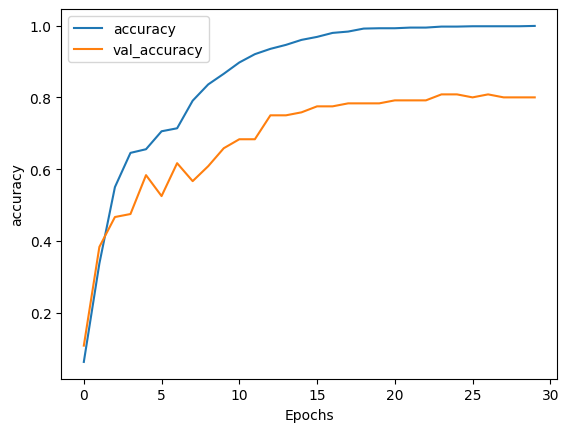

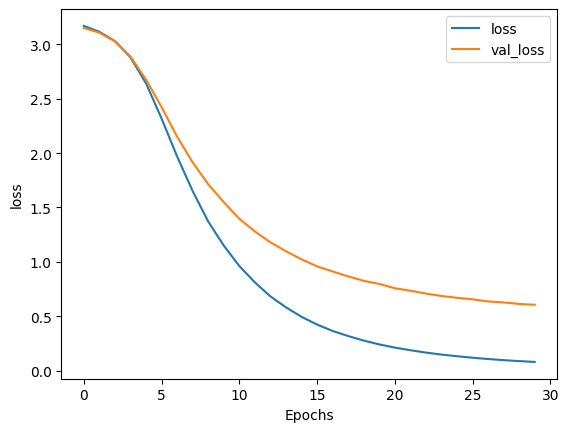

In [22]:
def plot_graphs(history, metric):
    plt.plot(history.history[metric])
    plt.plot(history.history[f'val_{metric}'])
    plt.xlabel("Epochs")
    plt.ylabel(metric)
    plt.legend([metric, f'val_{metric}'])
    plt.show()
    
plot_graphs(history, "accuracy")
plot_graphs(history, "loss")

## Visualizing 3D Vectors

In [23]:
# Reverse word index
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

# Save the embedding layer
e = model.layers[0]

# Save the weights of the embedding layer
weights = e.get_weights()[0]
print(f"Weights of embedding layer have shape: {weights.shape}")

Weights of embedding layer have shape: (1000, 16)


In [24]:
# Generate files for embedding visualization
out_v = io.open('vecs.tsv', 'w', encoding='utf-8')
out_m = io.open('meta.tsv', 'w', encoding='utf-8')

# Iterate through the range of word indices up to NUM_WORDS
for word_num in range(1, NUM_WORDS):
    if word_num in reverse_word_index:
        word = reverse_word_index[word_num]
        embeddings = weights[word_num]
        out_m.write(word + "\n")
        out_v.write('\t'.join([str(x) for x in embeddings]) + "\n")

out_v.close()
out_m.close()

## Final Evaluation

In [25]:
model.evaluate(x=val_padded_seq,y=val_label_seq,batch_size=10)

12/12 [==============================] - 0s 6ms/step - loss: 0.6053 - accuracy: 0.8000


[0.605292558670044, 0.800000011920929]

In [26]:
y_holdout_proba = model.predict(val_padded_seq) # This step predicts probabilities
# Next, we predict the labels
y_holdout_pred = np.argmax(y_holdout_proba,axis=1)

4/4 [==============================] - 0s 9ms/step


In [27]:
# Assuming you have your label_tokenizer from tokenize_labels function
def create_label_index(all_labels):
    label_tokenizer = Tokenizer()
    label_tokenizer.fit_on_texts(all_labels)
    # Creating a reverse mapping from numeric index to label name
    index_to_label = {v-1: k for k, v in label_tokenizer.word_index.items()}  # v-1 because tokenizer starts with 1
    return index_to_label

index_to_label = create_label_index(labels)
# Generate a list of label names sorted by their index (assuming label indices are continuous and start from 0)
unique_label_names = [index_to_label[i] for i in range(len(index_to_label))]


In [28]:
# Assuming label_tokenizer is already set up from previous steps
unique_label_names = [label for label, index in sorted(label_tokenizer.word_index.items(), key=lambda x: x[1])]


In [29]:
from sklearn.metrics import classification_report

# Assuming y_holdout_pred are the predictions from your model for the validation set
print(classification_report(val_label_seq, y_holdout_pred, target_names=unique_label_names))


                                        precision    recall  f1-score   support

                        A01.0(TYPHOID)       0.57      0.80      0.67         5
                           A90(DENGUE)       0.62      1.00      0.77         5
                    B01.9(CHICKEN_POX)       0.56      1.00      0.71         5
                 B49(FUNGAL_INFECTION)       1.00      0.80      0.89         5
                        B50.9(MALARIA)       1.00      1.00      1.00         5
                        E089(DIABETES)       0.67      0.40      0.50         5
                     G43.909(MIGRAINE)       1.00      1.00      1.00         5
                     I10(HYPERTENSION)       0.83      1.00      0.91         5
               I83.899(VARICOSE_VEINS)       1.00      1.00      1.00         5
                      J00(COMMON_COLD)       1.00      0.40      0.57         5
                      J15.9(PNEUMONIA)       1.00      0.60      0.75         5
             J45.909(BRONCHI_ALASTHMA) 

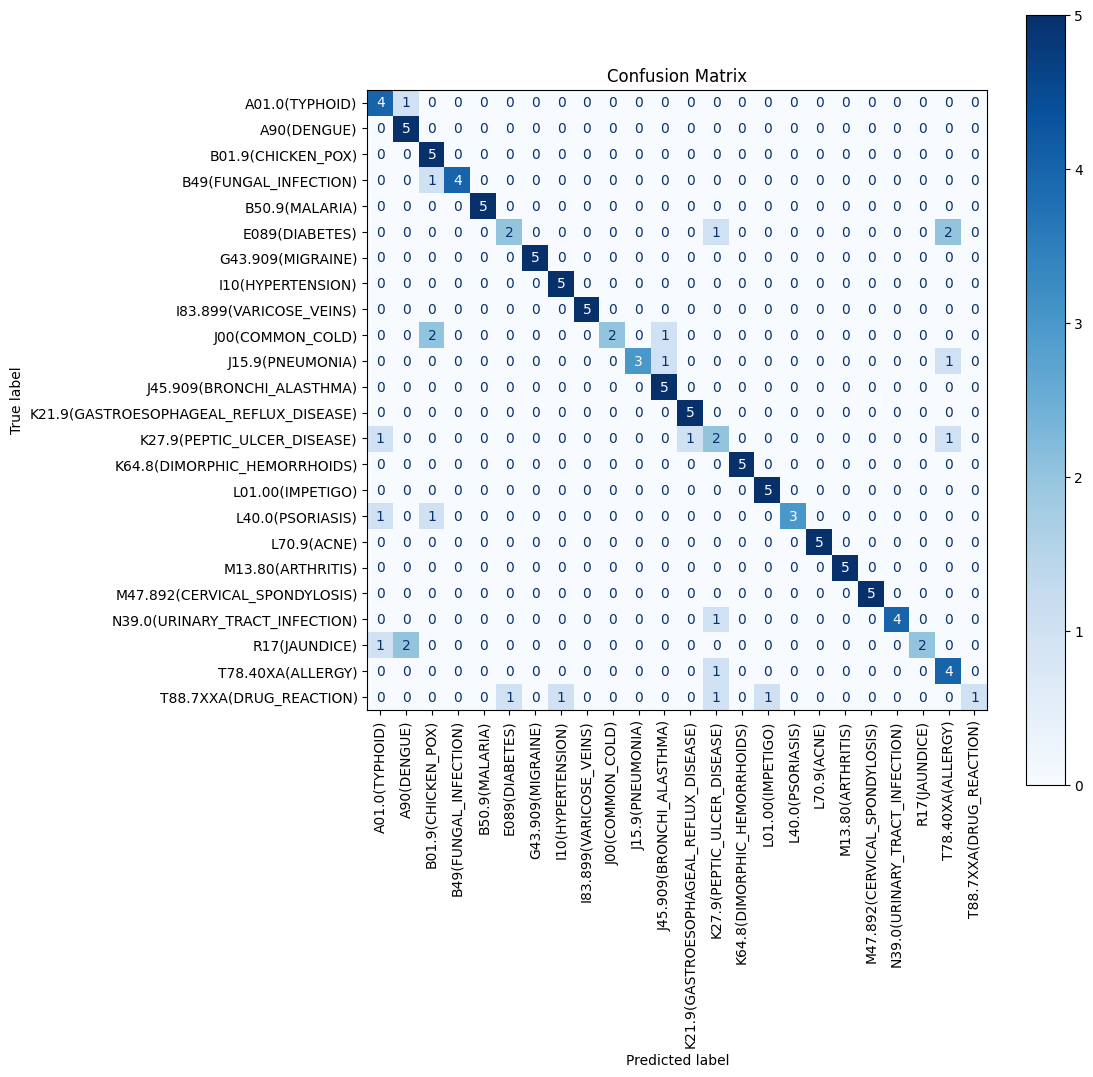

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def plot_confusion_matrix(true_labels, predictions, classes):
    cm = confusion_matrix(true_labels, predictions)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(10, 10))  # You can adjust the figure size as needed
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title('Confusion Matrix')
    plt.xticks(rotation=90)  # Rotate x-axis labels vertically
    plt.yticks(rotation=0)   # Ensure y-axis labels are horizontal for readability
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()

# Assuming `class_names` and other variables are already set from previous parts of your code
class_names = [label_tokenizer.index_word[i+1] for i in range(len(label_tokenizer.index_word)) if (i+1) in label_tokenizer.index_word]
plot_confusion_matrix(val_label_seq.flatten(), y_holdout_pred, class_names)


## Random forest

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import random

# Create and train the Random Forest model
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(train_padded_seq, train_label_seq)

# Validate the model
y_pred = random_forest_model.predict(val_padded_seq)
accuracy = accuracy_score(val_label_seq, y_pred)
print(f"Validation Accuracy: {accuracy:.2f}")


Validation Accuracy: 0.40


## Logistic Regression

In [32]:
from sklearn.linear_model import LogisticRegression

# Create and train the Logistic Regression model
logistic_model = LogisticRegression(random_state=42, max_iter=1000)
logistic_model.fit(train_padded_seq, train_label_seq)

# Validate the model
y_pred_logistic = logistic_model.predict(val_padded_seq)
accuracy_logistic = accuracy_score(val_label_seq, y_pred_logistic)
print(f"Logistic Regression Validation Accuracy: {accuracy_logistic:.2f}")


Logistic Regression Validation Accuracy: 0.14


## k-Nearest Neighbors (k-NN)

In [33]:
from sklearn.neighbors import KNeighborsClassifier

# Create and train the k-NN model
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(train_padded_seq, train_label_seq)

# Validate the model
y_pred_knn = knn_model.predict(val_padded_seq)
accuracy_knn = accuracy_score(val_label_seq, y_pred_knn)
print(f"k-NN Validation Accuracy: {accuracy_knn:.2f}")


k-NN Validation Accuracy: 0.15


## Naive Bayes

In [34]:
from sklearn.naive_bayes import MultinomialNB

# Create and train the Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(train_padded_seq, train_label_seq)

# Validate the model
y_pred_nb = nb_model.predict(val_padded_seq)
accuracy_nb = accuracy_score(val_label_seq, y_pred_nb)
print(f"Naive Bayes Validation Accuracy: {accuracy_nb:.2f}")


Naive Bayes Validation Accuracy: 0.12


## Comparsion between Accuracies

In [35]:
model_accuracies = {}


In [36]:
# Assuming 'history' is the history object returned by the model.fit() method of your TensorFlow model
tensorflow_val_accuracy = history.history['val_accuracy'][-1]  # Extracting last epoch validation accuracy

# Storing TensorFlow model accuracy in the dictionary
model_accuracies['TensorFlow Model'] = tensorflow_val_accuracy


In [37]:
# Random Forest model validation
random_forest_accuracy = accuracy_score(val_label_seq, y_pred)
model_accuracies['Random Forest'] = random_forest_accuracy

# Logistic Regression model validation
logistic_regression_accuracy = accuracy_score(val_label_seq, y_pred_logistic)
model_accuracies['Logistic Regression'] = logistic_regression_accuracy

# k-NN model validation
knn_accuracy = accuracy_score(val_label_seq, y_pred_knn)
model_accuracies['k-NN'] = knn_accuracy

# Naive Bayes model validation
naive_bayes_accuracy = accuracy_score(val_label_seq, y_pred_nb)
model_accuracies['Naive Bayes'] = naive_bayes_accuracy


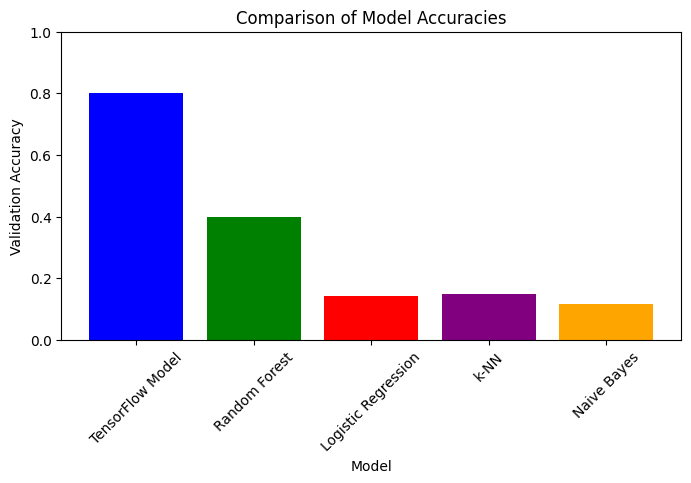

In [38]:
# Names of the models
model_names = list(model_accuracies.keys())
# Corresponding accuracy values
accuracies = list(model_accuracies.values())

# Creating the bar plot
plt.figure(figsize=(8, 4))  # Adjusting figure size for better visibility
plt.bar(model_names, accuracies, color=['blue', 'green', 'red', 'purple', 'orange'])  # Different color for each bar
plt.xlabel('Model')  # Label for the x-axis
plt.ylabel('Validation Accuracy')  # Label for the y-axis
plt.title('Comparison of Model Accuracies')  # Title of the plot
plt.ylim(0.0, 1.0)  # Set the limit for y-axis to standardize the view for accuracy
plt.xticks(rotation=45)  # Rotate model names for better visibility
plt.show()  # Display the plot


## Final Output

In [39]:
def preprocess_user_input(input_text, tokenizer):
    # Apply the same preprocessing as was done for the training data
    processed_text = remove_stopwords(input_text)
    # Tokenizing and padding
    seq = tokenizer.texts_to_sequences([processed_text])
    padded_seq = pad_sequences(seq, maxlen=40, padding='post')
    return padded_seq


In [40]:
def predict_disease(input_text, model, tokenizer, label_tokenizer):
    # Preprocess the text
    processed_seq = preprocess_user_input(input_text, tokenizer)
    # Predict
    prediction = model.predict(processed_seq)
    predicted_label_idx = np.argmax(prediction, axis=1)[0]
    # Convert label index to label
    predicted_label = label_tokenizer.index_word[predicted_label_idx + 1]  # +1 because index_word starts from 1
    # Show the predicted label and the probabilities for each class
    print("Predicted Disease:", predicted_label)
    print(f"Confidence: {prediction[0][predicted_label_idx]:.4f}")  # Show the confidence level of the predicted class
    print("\nConfidence Levels per Class:")
    for idx, prob in enumerate(prediction[0]):
        label = label_tokenizer.index_word[idx + 1] if (idx + 1) in label_tokenizer.index_word else "Unknown"
        print(f"{label}: {prob:.4f}")


In [ ]:
# Example usage
user_description = input("Enter your symptoms: ")
predict_disease(user_description, model, tokenizer, label_tokenizer)

## Now its completed
### Thanks for your time 

In [42]:
pip install googletrans==4.0.0-rc1


In [43]:
# Install googletrans if not installed
# !pip install googletrans==4.0.0-rc1


from googletrans import Translator

def translate_to_english(text):
    translator = Translator()
    translated = translator.translate(text, src='auto', dest='en')
    return translated.text

# Example usage integrating translation and prediction
user_description = input("Enter your symptoms: ")
english_description = translate_to_english(user_description)
predict_disease(english_description, model, tokenizer, label_tokenizer)


Enter your symptoms:  starting rashes arms neck. rash often bleeds hurts scratch it. also developed small dents nails, strange.


1/1 [==============================] - 0s 47ms/step
Predicted Disease: B01.9(CHICKEN_POX)
Confidence: 0.4465

Confidence Levels per Class:
A01.0(TYPHOID): 0.0040
A90(DENGUE): 0.1326
B01.9(CHICKEN_POX): 0.4465
B49(FUNGAL_INFECTION): 0.0201
B50.9(MALARIA): 0.0016
E089(DIABETES): 0.0040
G43.909(MIGRAINE): 0.0020
I10(HYPERTENSION): 0.0029
I83.899(VARICOSE_VEINS): 0.0175
J00(COMMON_COLD): 0.0069
J15.9(PNEUMONIA): 0.0017
J45.909(BRONCHI_ALASTHMA): 0.0133
K21.9(GASTROESOPHAGEAL_REFLUX_DISEASE): 0.0030
K27.9(PEPTIC_ULCER_DISEASE): 0.0024
K64.8(DIMORPHIC_HEMORRHOIDS): 0.0015
L01.00(IMPETIGO): 0.0503
L40.0(PSORIASIS): 0.1758
L70.9(ACNE): 0.0071
M13.80(ARTHRITIS): 0.0180
M47.892(CERVICAL_SPONDYLOSIS): 0.0625
N39.0(URINARY_TRACT_INFECTION): 0.0034
R17(JAUNDICE): 0.0166
T78.40XA(ALLERGY): 0.0055
T88.7XXA(DRUG_REACTION): 0.0008
